<a href="https://colab.research.google.com/github/defedoj/lab1_done/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 15.1 MB/s eta 0:00:00
(516377, 4) (800, 7)
bad type: 0
bad tariff: 0
bad heat: 0
ts out: 0
conn_yr out: 0
yrs_conn out: 0
uniq m/r: 800 800
bad id before: 96
bad id after: 0
bad dist before: 80
bad dist after: 0
merged: 516377 | na type: 0
dup diff: 0
after dedup: 516377
Wh meters: 64
max kWh ratio: 4.493221104959892
min Wh ratio: 298.33307368749024


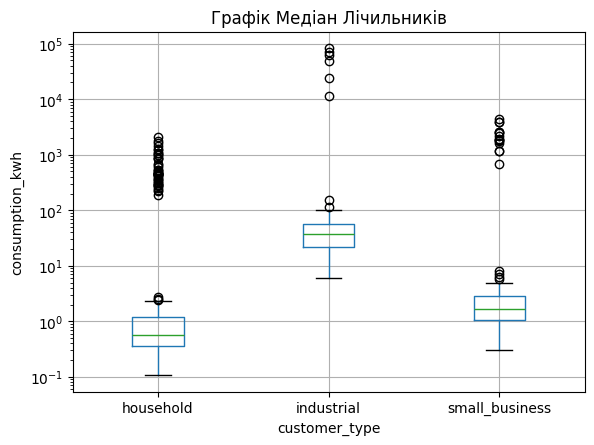

out of bounds: 0
silent: 48
max normal silence: 1.0
min silent silence: 144.0
frozen: 40
min normal ratio: 0.844311377245509
max frozen ratio: 0.4977307110438729


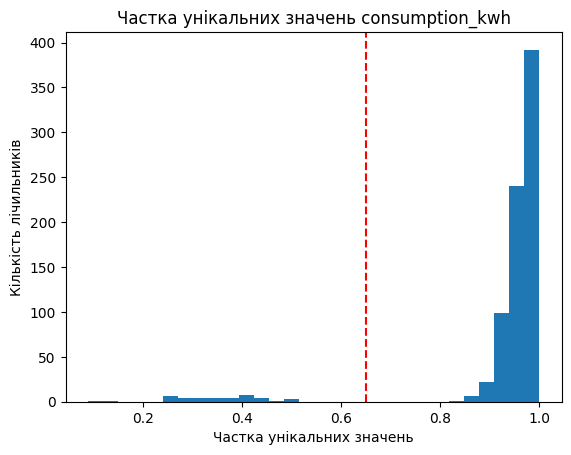

copies: [('connection_year', 'years_connected', np.float64(0.9990474092701417))]
saved: (516377, 8)
regr meters: 483
a=11.06, b1=20.99, b2=1.63, R2=0.700


In [ ]:
!pip install pyarrow fastparquet -q

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import warnings

warnings.filterwarnings('ignore')

df_meters = pd.read_parquet("meters.parquet")
df_registry = pd.read_csv("registry.csv")

print(df_meters.shape, df_registry.shape)

print("bad type:", (~df_registry["customer_type"].isin(["household", "small_business", "industrial"])).sum())
print("bad tariff:", (~df_registry["tariff"].isin(["single", "dual_zone"])).sum())
print("bad heat:", (~df_registry["electric_heating"].isin([0, 1])).sum())
print("ts out:", (~df_meters["ts"].between("2026-01-05 00:00", "2026-02-01 23:00")).sum())
print("conn_yr out:", (~df_registry["connection_year"].between(1985, 2024)).sum())
print("yrs_conn out:", (~df_registry["years_connected"].between(1, 41)).sum())
print("uniq m/r:", df_meters["meter_id"].nunique(), df_registry["meter_id"].nunique())

print("bad id before:", (~df_registry["meter_id"].str.fullmatch(r"UA\d{6}")).sum())
df_registry["meter_id"] = df_registry["meter_id"].str.strip().str.lstrip("0")
print("bad id after:", (~df_registry["meter_id"].str.fullmatch(r"UA\d{6}")).sum())

districts = ("Podil", "Solomianka", "Darnytsia", "Obolon", "Sviatoshyn")
print("bad dist before:", (~df_registry["district"].isin(districts)).sum())
df_registry["district"] = df_registry["district"].str.strip().str.capitalize()
print("bad dist after:", (~df_registry["district"].isin(districts)).sum())

df = df_meters.merge(df_registry, on="meter_id", how="left", validate="m:1")
print("merged:", len(df), "| na type:", df["customer_type"].isna().sum())

u_group = df[["meter_id", "ts"]].drop_duplicates().shape[0]
print("dup diff:", len(df) - u_group)
df = df.sort_values("record_ts").drop_duplicates(subset=["meter_id", "ts"], keep="last")
print("after dedup:", len(df))

meter_median = df.groupby("meter_id")["consumption_kwh"].median()
meter_type = df.groupby("meter_id")["customer_type"].first()
type_median = df.groupby("customer_type")["consumption_kwh"].median()

ratio = meter_median / meter_type.map(type_median)
watt_meters = ratio[ratio > 100]
normal_ratio = ratio[ratio <= 100]

print("Wh meters:", len(watt_meters))
print("max kWh ratio:", normal_ratio.max())
if len(watt_meters) > 0: print("min Wh ratio:", watt_meters.min())

median_df = pd.DataFrame({"meter_median": meter_median, "customer_type": meter_type})
median_df.boxplot(column="meter_median", by="customer_type")
plt.yscale("log")
plt.suptitle("")
plt.title("Графік Медіан Лічильників")
plt.ylabel("consumption_kwh")
plt.savefig("Графік Медіан Лічильників.png", bbox_inches='tight', dpi=150)
plt.show()

df.loc[df["meter_id"].isin(watt_meters.index), "consumption_kwh"] /= 1000

min_kwh = {"household": 0.01, "small_business": 0.02, "industrial": 1}
max_kwh = {"household": 10, "small_business": 60, "industrial": 1200}
valid_cons = df["consumption_kwh"].between(df["customer_type"].map(min_kwh), df["customer_type"].map(max_kwh))
print("out of bounds:", (~valid_cons).sum())

ts_end = pd.Timestamp("2026-02-01 23:00")
silent_hours = (ts_end - df.groupby("meter_id")["ts"].max()) / pd.Timedelta(hours=1)
silent_mask = silent_hours > 48
silent = list(silent_hours[silent_mask].index)

print("silent:", len(silent))
print("max normal silence:", silent_hours[~silent_mask].max())
if silent: print("min silent silence:", silent_hours[silent_mask].min())

unique_ratio = df.groupby("meter_id")["consumption_kwh"].nunique() / df.groupby("meter_id")["consumption_kwh"].size()
frozen_mask = unique_ratio < 0.65
frozen = list(unique_ratio[frozen_mask].index)

print("frozen:", len(frozen))
print("min normal ratio:", unique_ratio[~frozen_mask].min())
if frozen: print("max frozen ratio:", unique_ratio[frozen_mask].max())

plt.figure()
plt.hist(unique_ratio, bins=30)
plt.axvline(0.65, linestyle="--", color='red')
plt.xlabel("Частка унікальних значень")
plt.ylabel("Кількість лічильників")
plt.title("Частка унікальних значень consumption_kwh")
plt.savefig("Частка унікальних значень.png", bbox_inches='tight', dpi=150)
plt.show()

corr = df.select_dtypes("number").corr().abs()
copies = [(a, b, corr.loc[a, b]) for a in corr.columns for b in corr.columns if a < b and corr.loc[a, b] > 0.95]
print("copies:", copies)

result = df.drop(columns=["years_connected", "record_ts"])

assert not result.duplicated(["meter_id", "ts"]).any()
assert result["meter_id"].nunique() == 800
assert result["meter_id"].str.fullmatch(r"UA\d{6}").all()
assert result["customer_type"].notna().all()
assert result["district"].isin(districts).all()
assert result["consumption_kwh"].between(result["customer_type"].map(min_kwh), result["customer_type"].map(max_kwh)).all()
assert "record_ts" not in result

result.to_parquet("cleaned.parquet", index=False)
print("saved:", result.shape)

homes = result[(result["customer_type"] == "household") & (~result["meter_id"].isin(silent)) & (~result["meter_id"].isin(frozen))]
per_meter = homes.groupby("meter_id").agg(kwh_per_day=("consumption_kwh", "mean"), electric_heating=("electric_heating", "first"), tariff=("tariff", "first"))
per_meter["kwh_per_day"] *= 24
per_meter["dual_zone"] = (per_meter["tariff"] == "dual_zone").astype(int)

x, y = per_meter[["electric_heating", "dual_zone"]], per_meter["kwh_per_day"]
model = LinearRegression().fit(x, y)

print("regr meters:", len(per_meter))
print(f"a={model.intercept_:.2f}, b1={model.coef_[0]:.2f}, b2={model.coef_[1]:.2f}, R2={model.score(x, y):.3f}")